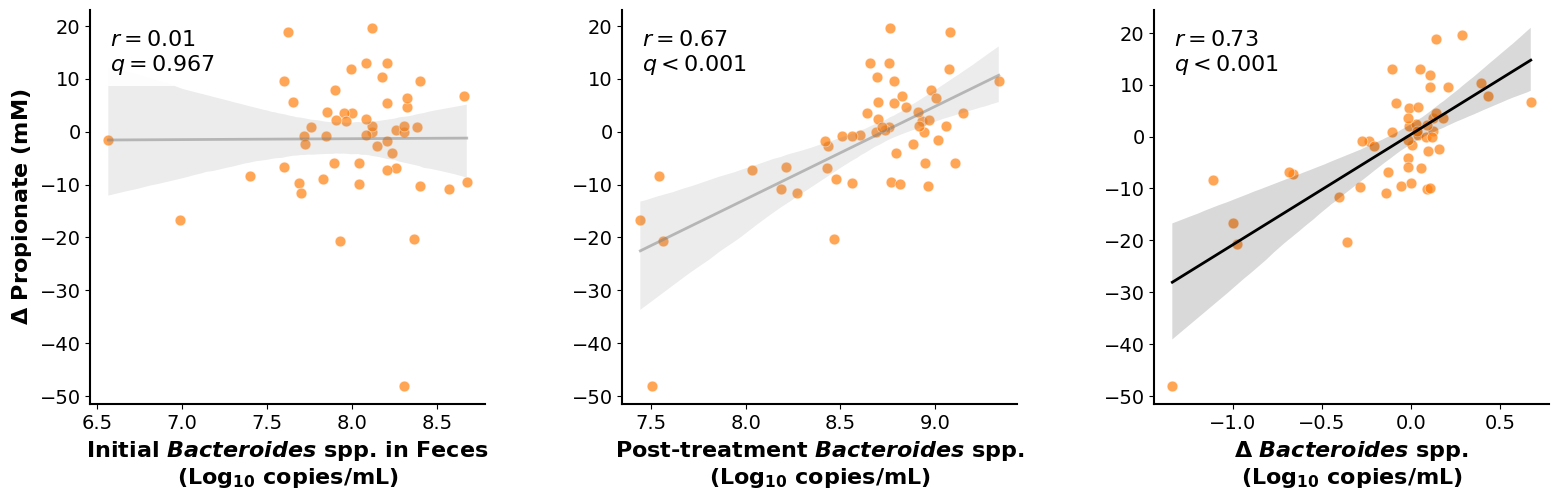

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
import statsmodels.stats.multitest as multitest
import re
import warnings

warnings.filterwarnings('ignore')

# =============================================================================
# 1. Visualization Settings & Mathtext Configuration
# =============================================================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# Override mathtext rules to enforce Bold Italic for \mathbf
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.bf'] = 'Arial:italic:bold'
plt.rcParams['mathtext.it'] = 'Arial:italic'
plt.rcParams['mathtext.default'] = 'regular'

def fix_sci_notation(val):
    if pd.isna(val):
        return val
    s = str(val).strip()
    s = re.sub(r'(\d+\.\d+)\.(E[+-]\d+)', r'\1\2', s)
    return s

def clean_and_convert_strict(vals):
    s_vals = pd.Series(vals).astype(str)
    s_vals = s_vals.replace(['Undetermined', '-', 'nan', 'NaN', '#VALUE!', ''], np.nan)
    s_vals = s_vals.apply(fix_sci_notation)
    return pd.to_numeric(s_vals, errors='coerce')

def get_p_text(p):
    if p < 0.001:
        return "< 0.001"
    else:
        return f"= {p:.3f}"

# =============================================================================
# 2. Data Processing (Mannose)
# =============================================================================
df_prop = pd.read_csv('Propionate(mM).csv')
df_bact = pd.read_csv('Bacteroides(qPCR).csv')
donor_cols = [c for c in df_prop.columns if c.startswith('HS-')]

def get_data_row(df, condition):
    mask = df['KULFFI'] == condition
    if not mask.any(): return pd.Series(np.nan, index=donor_cols)
    return clean_and_convert_strict(df.loc[mask, donor_cols].iloc[0])

prop_ctrl = get_data_row(df_prop, 'Control')
prop_target = get_data_row(df_prop, 'Mannose')
delta_prop = prop_target - prop_ctrl

bact_feces = get_data_row(df_bact, 'Feces slurry')
bact_ctrl = get_data_row(df_bact, 'Control')
bact_target = get_data_row(df_bact, 'Mannose')

bact_initial = np.log10(bact_feces + 1)
df_initial = pd.DataFrame({'X': bact_initial, 'Y': delta_prop}).dropna()

bact_post = np.log10(bact_target + 1)
df_post = pd.DataFrame({'X': bact_post, 'Y': delta_prop}).dropna()

bact_delta = np.log10(bact_target + 1) - np.log10(bact_ctrl + 1)
df_delta = pd.DataFrame({'X': bact_delta, 'Y': delta_prop}).dropna()

p_values = []
r_values = []
for df in [df_initial, df_post, df_delta]:
    r, p = stats.pearsonr(df['X'], df['Y'])
    r_values.append(r)
    p_values.append(p)

_, q_values, _, _ = multitest.multipletests(p_values, alpha=0.05, method='fdr_bh')

# =============================================================================
# 3. Figure Generation
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
plot_color = '#ff7f0e'  # Orange for Mannose

def plot_panel(ax, df, r_val, q_val, xlabel, ylabel, show_ylabel=False, is_highlight=False):
    # Highlight configuration: Black, fully opaque line for the main result
    line_c = 'black' if is_highlight else 'gray'
    line_a = 1.0 if is_highlight else 0.5

    sns.regplot(x='X', y='Y', data=df, ax=ax, color=plot_color,
                scatter_kws={'s': 60, 'alpha': 0.7, 'edgecolor': 'white', 'linewidths': 0.5},
                line_kws={'linewidth': 2, 'color': line_c, 'alpha': line_a, 'linestyle': '-'})

    ax.set_xlabel(xlabel, fontsize=16, fontweight='bold')

    if show_ylabel:
        ax.set_ylabel(ylabel, fontsize=16, fontweight='bold')
    else:
        ax.set_ylabel('')

    stats_text = f"$\\mathit{{r}} = {r_val:.2f}$\n$\\mathit{{q}} {get_p_text(q_val)}$"

    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=16, fontweight='normal', va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.9, edgecolor='none'))

    for spine in ['left', 'bottom']:
        ax.spines[spine].set_linewidth(1.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_box_aspect(1)
    ax.tick_params(axis='both', labelsize=14)

# Panel a (Initial Feces - Background Line)
plot_panel(axes[0], df_initial, r_values[0], q_values[0],
           r'Initial $\mathbf{Bacteroides}$ spp. in Feces' + '\n(Log$_{10}$ copies/mL)',
           r'$\Delta$ Propionate (mM)', show_ylabel=True, is_highlight=False)

# Panel b (Post-treatment - Background Line)
plot_panel(axes[1], df_post, r_values[1], q_values[1],
           r'Post-treatment $\mathbf{Bacteroides}$ spp.' + '\n(Log$_{10}$ copies/mL)',
           r'$\Delta$ Propionate (mM)', show_ylabel=False, is_highlight=False)

# Panel c (Delta - Highlighted Black Line)
plot_panel(axes[2], df_delta, r_values[2], q_values[2],
           r'$\Delta$ $\mathbf{Bacteroides}$ spp.' + '\n(Log$_{10}$ copies/mL)',
           r'$\Delta$ Propionate (mM)', show_ylabel=False, is_highlight=True)

plt.tight_layout(w_pad=4.0)

# =============================================================================
# 4. Output
# =============================================================================
output_file = 'Figure_3i.pdf'
plt.savefig(output_file, dpi=600, bbox_inches='tight', transparent=True)